# A first static two-factor IRT model

Ten binary items, two latent traits, and one response per person: this is a small example of **confirmatory multidimensional item response theory** with `dynamirt`. We will simulate responses, fit a two-parameter logistic (2PL) model, inspect sampling diagnostics, and interpret the fitted items.

The first five items measure `latent_0`; the remaining five measure `latent_1`. Think of these as two skills in a short test. Each item has a discrimination (how strongly it responds to the skill) and an intercept (how readily it receives a positive response).

Run the notebook from top to bottom in an environment with `dynamirt`, ArviZ 1.x, and Jupyter installed. The four-chain MCMC fit is the most expensive step; its runtime depends on your hardware.

In [1]:
import numpyro

# Set CPU device count before JAX initializes, so four chains can run in parallel.
numpyro.set_host_device_count(4)

import arviz as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from numpyro.infer import Predictive

from dynamirt import Confirmatory, dynamirt, fit_mcmc, q_matrix
from dynamirt.diagnostics import item_curves, plot_item_curves, plot_loadings

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

/home/jrc002/anaconda3/envs/jax_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jrc002/anaconda3/envs/jax_env/lib/python3.12/site-packages/jax/experimental/sparse/linalg.py:34: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  import scipy.sparse


## 1. Make a small response dataset

`responses` is a numeric array with one row per person and one column per item. Binary responses use `0` and `1`; in your own data, use `np.nan` for missing responses.

The **Q matrix** has one row per item and one column per latent trait. A `1` allows a loading to be estimated; a `0` fixes it to zero. `q_matrix` builds this pattern from lists of item positions. We will use the same pattern to select the items in our plots.

In [2]:
n, p, k = 500, 10, 2
item_names = [f"item_{j}" for j in range(p)]
latent_names = [f"latent_{j}" for j in range(k)]
Q = q_matrix([np.arange(5), np.arange(5, 10)], items=p)

The simulation uses independent standard-normal skills and positive loadings. Its response probability is

$$P(Y_{ij}=1)=\operatorname{logit}^{-1}\!\left(d_j+\sum_{\ell} a_{j\ell}\theta_{i\ell}\right).$$

Here $d_j$ is an **additive intercept**, so larger values make a positive response more likely. It is not the usual IRT difficulty: for an item with a single positive loading, difficulty is $-d_j/a_j$.

In [3]:
rng = np.random.default_rng(0)
theta_true = rng.standard_normal((n, k))
a_true = np.where(Q, rng.uniform(0.8, 2.0, (p, k)), 0.0)
d_true = rng.normal(0, 0.5, p)

logits = theta_true @ a_true.T + d_true
probabilities = 1 / (1 + np.exp(-logits))
responses = (rng.random((n, p)) < probabilities).astype(float)

A quick look at the first 20 people helps confirm the orientation of the array. The vertical line separates the two groups of items; variation within each group is expected even for people with similar skills.

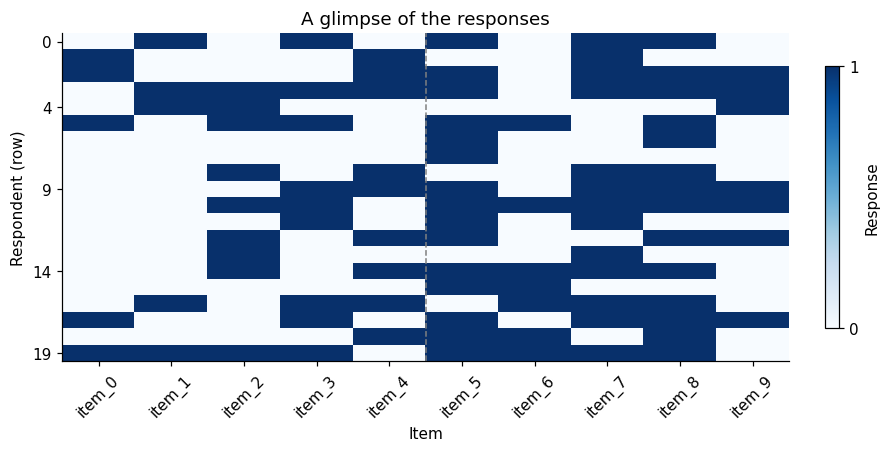

In [4]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
image = ax.imshow(responses[:20], cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.axvline(4.5, color="0.5", linewidth=1, linestyle="--")
ax.set(xticks=np.arange(p), xticklabels=item_names,
       yticks=[0, 4, 9, 14, 19], yticklabels=[0, 4, 9, 14, 19],
       xlabel="Item", ylabel="Respondent (row)", title="A glimpse of the responses")
ax.tick_params(axis="x", labelrotation=45)
fig.colorbar(image, ax=ax, ticks=[0, 1], label="Response", shrink=0.8)
plt.show()

## 2. Specify and fit the model

`dynamirt(...)` builds a NumPyro model; `fit_mcmc(...)` runs inference. `Confirmatory(Q, positive=Q)` estimates only the permitted loadings and constrains all of them to be positive. This expresses our assumption that greater skill increases the probability of a positive response and fixes each factor's direction.

With no `latent_fn`, the builder supplies one latent score vector per response row. Here we assume that factors are uncorrelated. In the static case, we could set `corr=True` to estimate a full correlation matrix between the latent traits.

There are no predictors here, so `covariates` is empty. Warmup adapts the sampler; `num_samples` is the number of retained draws **per chain**. The returned `FitResult` exposes the NumPyro sampler as `result.inference` and labeled posterior data through `result.to_idata()`.

In [5]:
model = dynamirt(
    model_type="2PL",
    n_latent=k,
    loadings=Confirmatory(Q, positive=Q)
)

covariates = {}
result = fit_mcmc(
    model, responses, covariates,
    rng_key=jax.random.PRNGKey(1),
    mcmc_kwargs={"num_warmup": 1500, "num_samples": 2000, "num_chains": 4,
                 "progress_bar": False},
)

Attach readable coordinate labels when converting to ArviZ data. These names follow the original column order and are then used for selection, heatmap labels, and item curves. Conversion preserves the separate chains needed for convergence diagnostics.

In [6]:
idata = result.to_idata(coords={"item": item_names, "latent": latent_names})

## 3. Check the sampler before interpreting the model

First check for divergent transitions; ideally there are none. Then summarize the least reassuring diagnostic in each parameter group: **maximum R-hat** (values near 1 indicate agreement between chains) and **minimum bulk ESS** (larger values indicate more effective information). Taking the maximum ESS would hide poorly sampled parameters. Tail ESS is also useful when reporting interval endpoints.

The table below covers the item intercepts, estimated loadings, and latent scores. Fixed zero loadings are excluded because they are not sampled parameters. We also omit duplicate internal representations of these same quantities. R-hat above about 1.01 deserves investigation; acceptable ESS depends on the precision you need. These summaries are a first check, not proof of convergence.

In [7]:
divergences = int(result.inference.get_extra_fields()["diverging"].sum())
print(f"Divergent transitions: {divergences:,}")

post = idata["posterior"].to_dataset()
# Select only active entries from the item-by-latent loading matrix.
active_positions = np.flatnonzero(Q.ravel())
active_loadings = post["loadings"].stack(loading=("item", "latent")).isel(
    loading=active_positions
).reset_index("loading", drop=True)

# The item intercept contribution is constant across observation rows.
diagnostic_posterior = xr.Dataset({
    "Item intercepts": post["item_intercept_eta"].isel(obs=0, drop=True),
    "Active loadings": active_loadings,
    "Latent scores": post["theta"],
})
rhat = az.rhat(diagnostic_posterior)
ess_bulk = az.ess(diagnostic_posterior, method="bulk")
ess_tail = az.ess(diagnostic_posterior, method="tail")

diagnostic_table = pd.DataFrame({
    "Max R-hat": {name: float(rhat[name].max(skipna=False)) for name in diagnostic_posterior},
    "Min bulk ESS": {name: float(ess_bulk[name].min(skipna=False)) for name in diagnostic_posterior},
    "Min tail ESS": {name: float(ess_tail[name].min(skipna=False)) for name in diagnostic_posterior},
})
display(diagnostic_table.style.format({
    "Max R-hat": "{:.3f}", "Min bulk ESS": "{:,.0f}", "Min tail ESS": "{:,.0f}",
}))

Divergent transitions: 0


,Max R-hat,Min bulk ESS,Min tail ESS
Item intercepts,1.002,"3,829","4,307"
Active loadings,1.004,"1,723","2,237"
Latent scores,1.004,"7,209","4,344"


## 4. Read the loadings and item curves

Dynamirt provides helper functions to easily check the estimated loadings (`plot_loadings`) and item response functions (`item_curves`, `plot_item_curves`). 

The heatmap shows posterior median loadings with 95% highest-density intervals (HDIs). Structural zeros come from `Q`; they are constraints, not discoveries. Larger positive loadings correspond to steeper item characteristic curves.

`item_curves` evaluates response probabilities while varying the selected latent trait and holding the other trait at zero. Passing our labeled `posterior` preserves the names. `plot_item_curves` selects items **by name**, and plots the probability of a positive response. We only draw items allowed by `Q` on each factor, so unrelated items do not appear as flat lines. Notably, we can do that because one of our model assumptions is that `Q` has a simple structure, i.e., each item loads onto only one factor. In scenarios with two factors and a `Q` that permits cross loadings, the functions can plot 2D heatmaps interpretable as decision boundaries instead.

All three plotting calls accept `ax`, which lets us compose them in one Matplotlib figure. Curve ribbons are pointwise 95% HDIs; they show uncertainty in the probabilities.

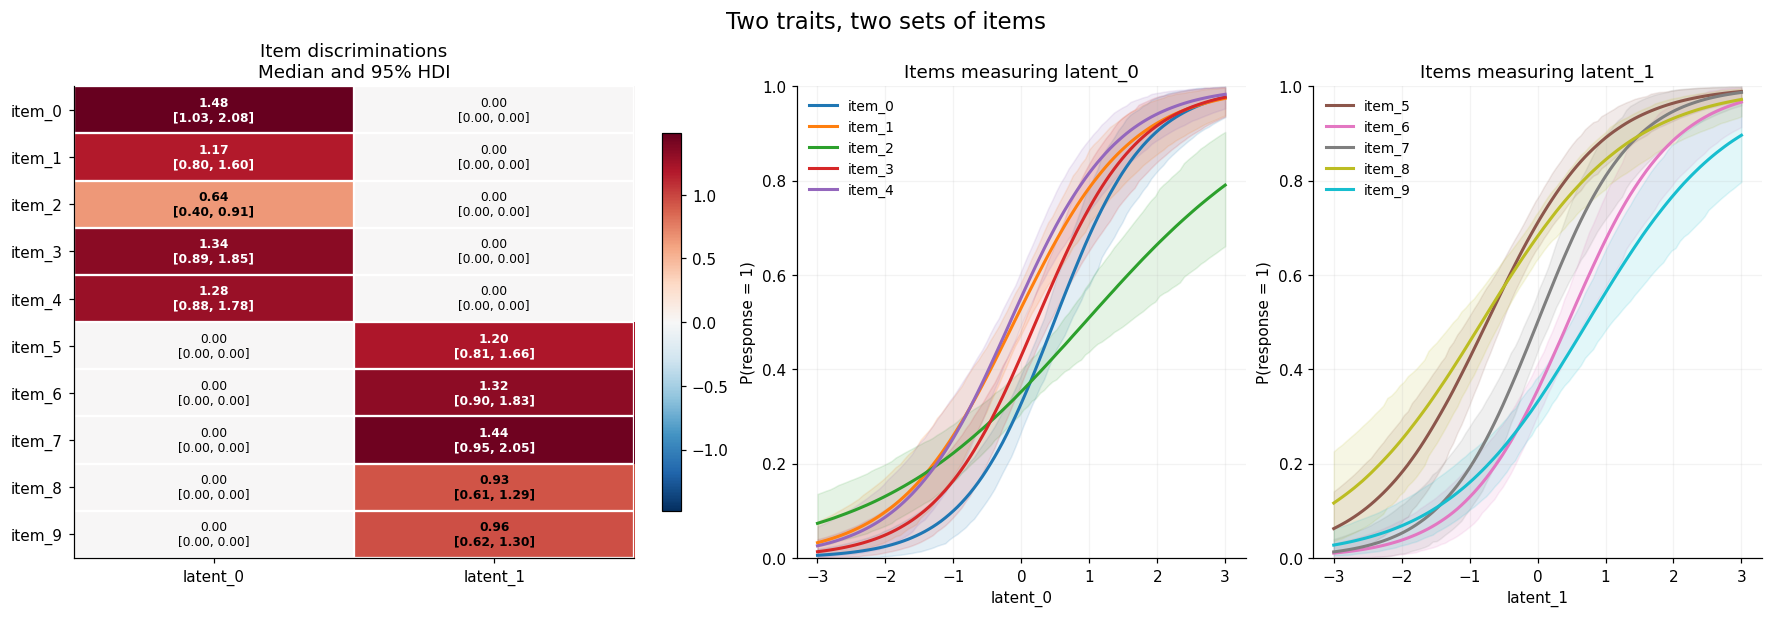

In [8]:
fig, axes = plt.subplots(
    1, 3, figsize=(16, 5.5), layout="constrained",
    gridspec_kw={"width_ratios": [1.25, 1, 1]},
)
plot_loadings(idata, ax=axes[0], text_kwargs={"fontsize": 8})
axes[0].set_title("Item discriminations\nMedian and 95% HDI")

colors = plt.get_cmap("tab10").colors
for factor, (latent, ax) in enumerate(zip(latent_names, axes[1:])):
    curves = item_curves(result, posterior=post, latent=[latent])
    for j in np.flatnonzero(Q[:, factor]):
        plot_item_curves(
            curves, item=item_names[j], category=1, ax=ax,
            line_kwargs={"color": colors[j], "label": item_names[j], "linewidth": 2},
            fill_kwargs={"alpha": 0.12},
        )
    ax.set(title=f"Items measuring {latent}", xlabel=latent,
           ylabel="P(response = 1)", ylim=(0, 1))
    ax.grid(alpha=0.15)
    ax.legend(frameon=False, fontsize=9, loc="upper left")

plt.show()

## 5. Did we recover the simulated item parameters?

Because these data are simulated, we can compare estimates with the values used to generate them. Points near the diagonal indicate good recovery; the vertical bars are central 95% posterior intervals. We compare only active loadings. These equal-tailed intervals differ slightly from the HDIs used above.

With real responses the true values are unknown, so this is a simulation check rather than a routine analysis step. Some misses are expected from finite data, even when the model is correctly specified.

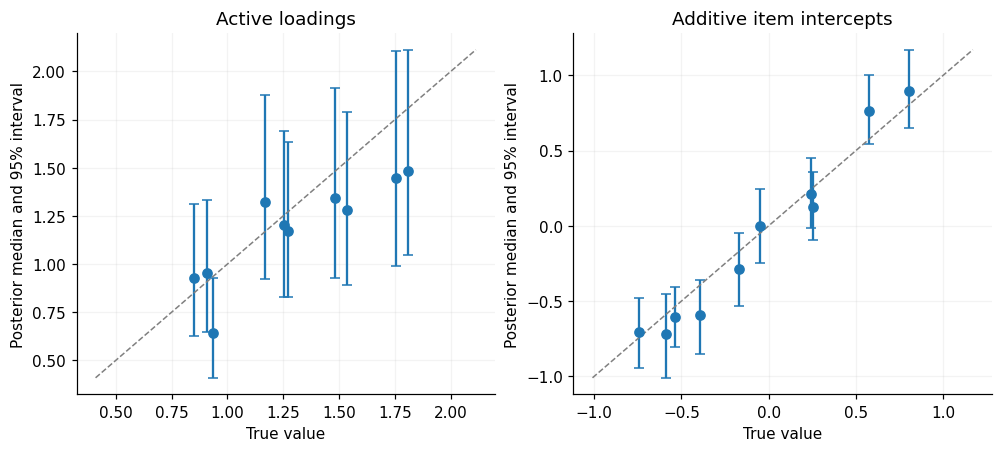

In [9]:
rows, cols = np.nonzero(Q)
loading_draws = (
    post["loadings"].transpose("chain", "draw", "item", "latent")
    .values[:, :, rows, cols].reshape(-1, len(rows))
)
intercept_draws = (
    post["item_intercept_eta"].isel(obs=0)
    .transpose("chain", "draw", "item").values.reshape(-1, p)
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")
for ax, truth, draws, title in [
    (axes[0], a_true[rows, cols], loading_draws, "Active loadings"),
    (axes[1], d_true, intercept_draws, "Additive item intercepts"),
]:
    lower, median, upper = np.quantile(draws, [0.025, 0.5, 0.975], axis=0)
    ax.errorbar(truth, median, yerr=[median - lower, upper - median],
                fmt="o", capsize=3, color="C0")
    limits = [min(truth.min(), lower.min()), max(truth.max(), upper.max())]
    ax.plot(limits, limits, "--", color="0.5", linewidth=1)
    ax.set(xlabel="True value", ylabel="Posterior median and 95% interval", title=title)
    ax.grid(alpha=0.15)
plt.show()

## 6. Can the fitted model reproduce item response rates?

A posterior predictive check asks whether simulated responses from the fitted model resemble the observed data. `Predictive` combines posterior draws with fresh Bernoulli outcomes. Passing `responses=None` requests new responses; `n_obs` and `n_var` supply the dimensions that would otherwise be inferred from the response array.

This check reuses the fitted respondents' latent scores, so it is an **in-sample check**, not prediction for new people. We use every eighth posterior draw to keep the replicated response array manageable.

In [10]:
posterior_samples = {
    name: draws[::8] for name, draws in result.inference.get_samples().items()
}
predictive = Predictive(model, posterior_samples=posterior_samples, return_sites=["Y"])
y_rep = predictive(
    jax.random.PRNGKey(2),
    responses=None,
    covariates=result.covariates,
    n_obs=n,
    n_var=p,
)["Y"]

Compare the observed proportion of positive responses with the posterior predictive median and 95% interval for each item. Large discrepancies suggest that the model misses an aspect of the response distribution.

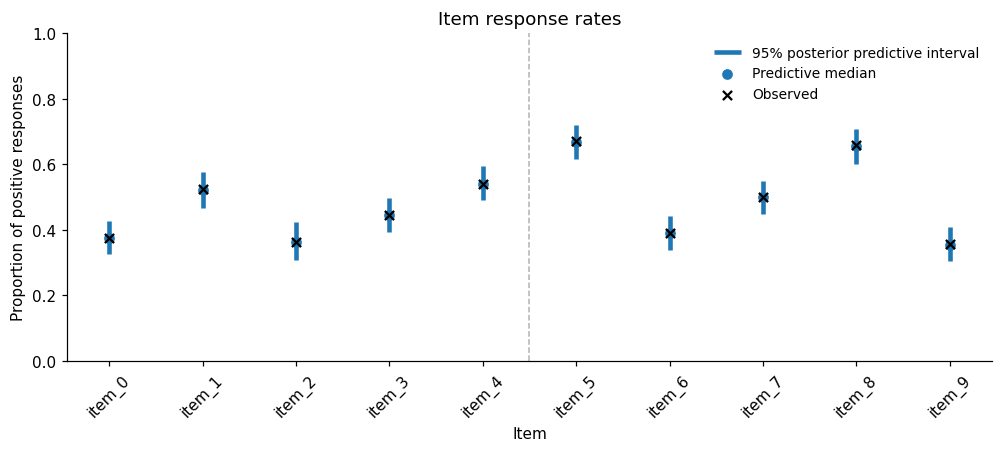

In [11]:
observed_rates = np.nanmean(responses, axis=0)
replicated_rates = np.asarray(y_rep).mean(axis=1)
lower, median, upper = np.quantile(replicated_rates, [0.025, 0.5, 0.975], axis=0)

items = np.arange(p)
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.vlines(items, lower, upper, color="C0", linewidth=3,
          label="95% posterior predictive interval")
ax.scatter(items, median, color="C0", label="Predictive median")
ax.scatter(items, observed_rates, color="black", marker="x", label="Observed", zorder=3)
ax.axvline(4.5, color="0.7", linestyle="--", linewidth=1)
ax.set(xticks=items, xticklabels=item_names, xlabel="Item",
       ylabel="Proportion of positive responses", ylim=(0, 1), title="Item response rates")
ax.tick_params(axis="x", labelrotation=45)
ax.legend(frameon=False, fontsize=9)
plt.show()

## Try your own data

Replace `responses` and the item names, then construct a Q matrix that reflects your measurement assumptions. Set `n_latent` to its number of columns. Revisit those assumptions and the sampling diagnostics before interpreting the fitted curves.